# SME Customer Churn — Exploratory Data Analysis

## Objective
Identify key drivers of SME customer churn to support targeted retention actions.

## Dataset
IBM Telco Customer Churn dataset (adapted for SME energy customers)


## 1. Churn Overview


In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/telco_customer_churn.csv")

# Quick look
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Calculate churn rate
churn_rate = (df['Churn'] == 'Yes').mean() * 100

churn_rate

np.float64(26.536987079369588)

Insight: Approximately ~27% of SME customers churn, indicating a significant revenue risk and justifying deeper diagnostic analysis.

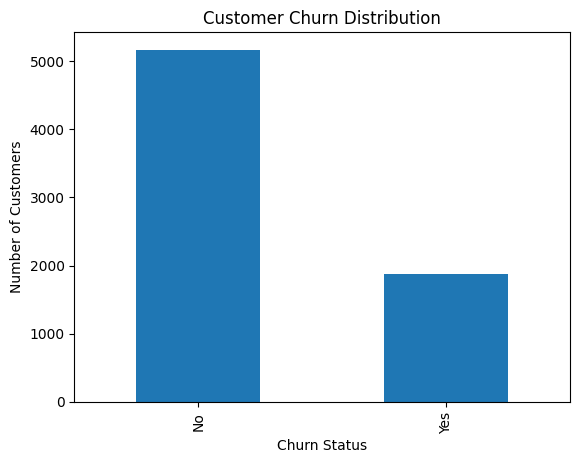

In [4]:
import matplotlib.pyplot as plt

# Churn distribution
churn_counts = df['Churn'].value_counts()

churn_counts.plot(
    kind='bar',
    title='Customer Churn Distribution',
)

plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

Visual Insight: While most customers are retained, the churned segment represents a substantial portion of the customer base, reinforcing the need for targeted retention strategies.

## 2. Tenure & Contract Analysis


In [5]:
# Average tenure by churn status
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

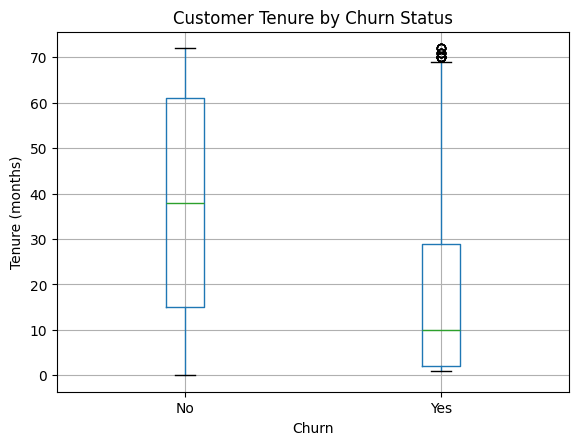

In [6]:
import matplotlib.pyplot as plt

# Tenure distribution by churn status
df.boxplot(column='tenure', by='Churn')

plt.title('Customer Tenure by Churn Status')
plt.suptitle('')  # remove automatic subtitle
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.show()


Insight: Customers who churn tend to have significantly shorter tenures, indicating that churn risk is highest early in the customer lifecycle.

In [7]:
# Churn rate by contract type
contract_churn = (
    df.groupby('Contract')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

Insight: Month-to-month contracts exhibit substantially higher churn rates compared to one-year and two-year contracts, indicating that longer-term contracts are a strong retention lever.

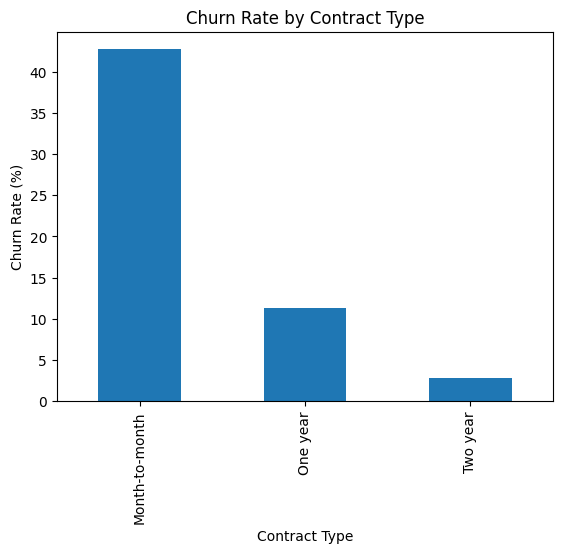

In [8]:
import matplotlib.pyplot as plt

# Plot churn rate by contract type
contract_churn.plot(
    kind='bar',
    title='Churn Rate by Contract Type'
)

plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

Visual Insight: Customers on month-to-month contracts churn at significantly higher rates, reinforcing the importance of contract length as a key retention mechanism.

## 3. Pricing & Payment Sensitivity


In [9]:
# Average monthly charges by churn status
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

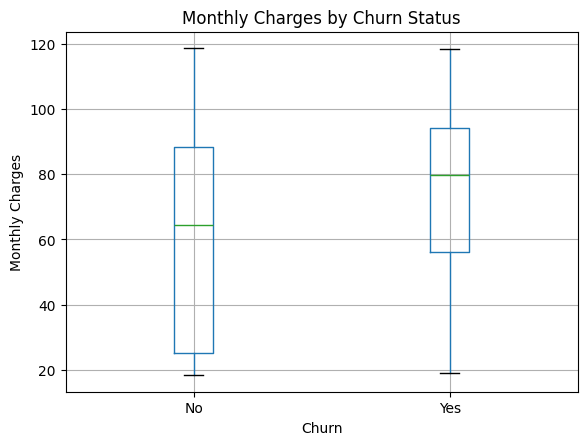

In [10]:
import matplotlib.pyplot as plt

# Monthly charges distribution by churn status
df.boxplot(column='MonthlyCharges', by='Churn')

plt.title('Monthly Charges by Churn Status')
plt.suptitle('')  # remove automatic subtitle
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

Insight: Customers who churn tend to have higher monthly charges, suggesting price sensitivity and potential value perception issues among higher-paying customers.

In [11]:
# Churn rate by payment method
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

Insight: Customers using electronic check payment methods exhibit significantly higher churn, while automatic payment methods are associated with lower churn, suggesting that payment convenience and commitment reduce churn risk.

## 4. Service & Feature Analysis


In [12]:
# Count number of services per customer
service_cols = [
    'PhoneService',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['service_count'] = df[service_cols].apply(
    lambda row: sum(row == 'Yes'), axis=1
)

# Average service count by churn status
df.groupby('Churn')['service_count'].mean()

Churn
No     3.036336
Yes    2.677368
Name: service_count, dtype: float64

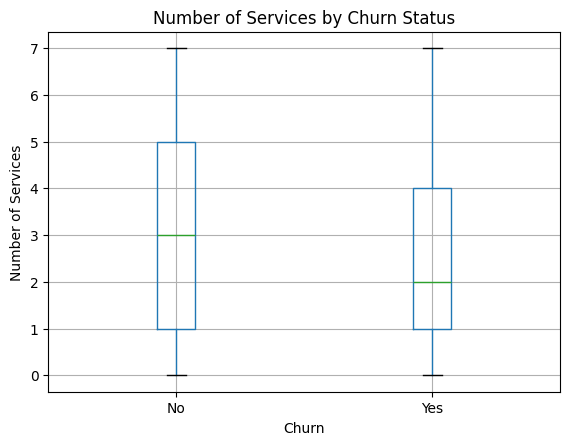

In [ ]:
import matplotlib.pyplot as plt

# Service count distribution by churn
df.boxplot(column='service_count', by='Churn')

plt.title('Number of Services by Churn Status')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Number of Services')
plt.show()

Insight: Customers who churn typically have fewer subscribed services, suggesting that deeper service engagement and bundling can significantly reduce churn risk.

## Key EDA Insights (Summary)


### Executive Summary of Findings

1. Churn is material: Approximately ~27% of SME customers churn, representing a significant revenue risk that warrants targeted intervention.

2. Early lifecycle churn dominates: Customers who churn have substantially shorter tenures, indicating that churn risk is highest early in the customer relationship.

3. Contract structure is a key lever: Month-to-month contracts exhibit significantly higher churn rates compared to longer-term contracts, making contract length one of the strongest retention mechanisms.

4. Price and engagement matter: Customers with higher monthly charges and fewer subscribed services are more likely to churn, suggesting that price sensitivity and lack of engagement drive attrition.